In [27]:
import pandas as pd
import numpy as np

jahr = '2024'

if jahr == '2025':
    wetter='Wetter/2024_Wetter_Station_020_Mengen_hh24.csv'
else:
    wetter='Wetter/2024_Wetter_Station_020_Mengen_hh24.csv'

wetter=pd.read_csv('Wetter/2024_Wetter_Station_020_Mengen_hh24.csv',sep=';',decimal=',')
wetter['Datum']=pd.to_datetime(wetter['Tag']+' '+wetter['Stunde'],format='%d.%m.%Y %H:%M',utc=True)
wetter=wetter.set_index('Datum')

In [28]:
waermebedarf=0.066 # kWh/h*K
# unter 22°C - 
pv_prod=67/5000 # 60kWh pro 5000 Globalstrahlung

In [29]:
wetter['PV']=pv_prod*wetter['SUM_GS200']
#Windkraft_je_ms['max W/m²']=Windkraft_je_ms.apply(lambda row: pow(min(row['m/s'],15),3)*0.5*1.2, axis= 1)
wetter['WP']=wetter.apply(lambda row: max(22-row['AVG_TA200'],0.5)*waermebedarf, axis=1)
wetter['Haus']=0.35

In [138]:
speicherkap=100
wetter['Speicher']=0.0
wetter['VerbrauchSpeicher']=0.0


In [199]:
r_arr=[]

for speicherkap in([0,1,2,3,4,5,6,7,8,9,10,12,15,20,21,22,23,24,25,26,50,75,80,100,500,2599,2600,2700]):
    speicher_alt=0
    #speicherkap=100
    wetter['Speicher']=0.0
    wetter['VerbrauchSpeicher']=0.0
    
    for cur in range(2):
        a_speicher=[]
        a_verbrauchspeicher=[]
        a_einspeicher=[]
        
        for index, row in wetter.iterrows():
            idx=index
    
            
            
            #rw=wetter.iloc[idx]
            delta=row['PV']-row['WP']-row['Haus']
    
            speicher_neu=max(min(speicherkap,delta+speicher_alt),0)
    
            verbrauch=max(speicher_alt-speicher_neu,0)
            einspeicher=min(speicher_alt-speicher_neu,0)
            
            a_speicher.append(speicher_neu)
            a_verbrauchspeicher.append(verbrauch)
            a_einspeicher.append(einspeicher)
            speicher_alt=speicher_neu
        wetter['VerbrauchSpeicher']=a_verbrauchspeicher
        wetter['Einspeicher']=a_einspeicher
        wetter['Speicher']=a_speicher

    wetter['Netz +']=wetter.apply(lambda row: max(row['WP']+row['Haus']-row['PV']-row['VerbrauchSpeicher']-row['Einspeicher'],0), axis=1)
    wetter['Netz -']=wetter.apply(lambda row: min(row['WP']+row['Haus']-row['PV']-row['VerbrauchSpeicher']-row['Einspeicher'],0), axis=1)
    wetter=wetter.round(6)
    r_arr.append([speicherkap,wetter['VerbrauchSpeicher'].sum()])

In [200]:
df=wetter.reset_index()
df['Monat']=df['Datum'].dt.month
df['Jahr']=df['Datum'].dt.year
res=pd.pivot_table(df,index='Monat',values=['PV','WP','Haus','Netz +','Netz -','VerbrauchSpeicher','Einspeicher'], aggfunc='sum',margins=True,margins_name=jahr)

In [201]:
res

,Einspeicher,Haus,Netz +,Netz -,PV,VerbrauchSpeicher,WP
Monat,,,,,,,
1,-146.42730,260.4,0.0,0.00000,394.89800,941.71090,929.7816
2,-411.34304,243.6,0.0,0.00000,680.83256,586.64328,612.5328
3,-826.99058,260.4,0.0,0.00000,1139.26398,566.00540,617.8788
4,-1186.33994,252.0,0.0,0.00000,1504.84412,451.24602,517.7502
5,-1715.07640,260.4,0.0,0.00000,1996.33200,310.41820,331.2738
6,-357.72598,252.0,0.0,-1571.28602,2149.25012,219.73648,187.9746
7,-205.88436,260.4,0.0,-1955.96676,2364.52782,204.41490,146.6916
8,-216.51494,260.4,0.0,-1943.99494,2339.15090,215.82478,134.0658
9,-355.21968,252.0,0.0,-678.97136,1246.03920,356.99804,316.8462


In [202]:
wetter['VerbrauchSpeicher'].sum()

6080.65594

In [209]:
df = pd.DataFrame(r_arr)
v = [0]+[r_arr[i+1][0]-r_arr[i][0] for i in range(len(r_arr)-1)]
r = [0]+[r_arr[i+1][1]-r_arr[i][1] for i in range(len(r_arr)-1)]
df[2]=v
df[3]=r
df[4]=df.apply(lambda row: row[3]/row[2] if (row[2]>0).any() else 0, axis=1)
df=df[(df[0]>0) & (df[0]<200)]

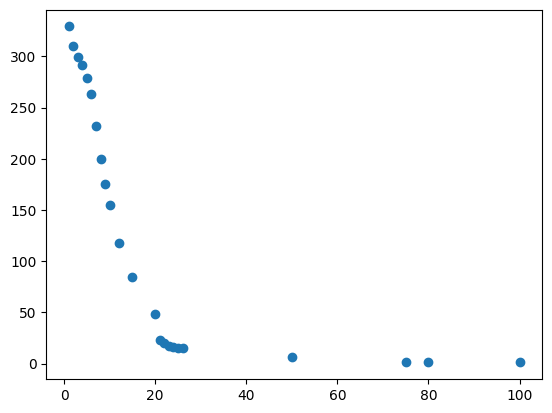

In [210]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
#ax.scatter([r[0] for r in r_arr],[r[1] for r in r_arr])

ax.scatter(df[0],df[4])
#ax.set_xscale('log')
#ax.set_yscale('log')
plt.show()

In [211]:
df

,0,1,2,3,4
1,1,329.25540,1,329.25540,329.255400
2,2,639.70144,1,310.44604,310.446040
3,3,939.10090,1,299.39946,299.399460
4,4,1230.88344,1,291.78254,291.782540
5,5,1510.24096,1,279.35752,279.357520
6,6,1773.56186,1,263.32090,263.320900
7,7,2005.80154,1,232.23968,232.239680
8,8,2205.86396,1,200.06242,200.062420
9,9,2381.16210,1,175.29814,175.298140
10,10,2535.97736,1,154.81526,154.815260


In [207]:
r_arr

[[0, 0],
 [1, 329.2554],
 [2, 639.70144],
 [3, 939.1009],
 [4, 1230.88344],
 [5, 1510.2409599999999],
 [6, 1773.5618599999998],
 [7, 2005.80154],
 [8, 2205.86396],
 [9, 2381.1621000000005],
 [10, 2535.9773600000003],
 [12, 2770.83576],
 [15, 3025.6964],
 [20, 3268.5919599999997],
 [21, 3291.93888],
 [22, 3312.31916],
 [23, 3329.3064799999997],
 [24, 3345.3064799999997],
 [25, 3360.4936],
 [26, 3375.30898],
 [50, 3527.1966199999997],
 [75, 3555.96544],
 [80, 3560.96544],
 [100, 3580.96544],
 [500, 3980.96544],
 [2599, 6079.96544],
 [2600, 6080.65594],
 [2700, 6080.65594]]

In [173]:
v=[0]+v

In [174]:
v

[0,
 329.2554,
 310.44604000000004,
 299.39946,
 291.78254000000004,
 279.3575199999998,
 263.32089999999994,
 232.23968000000013,
 200.0624200000002,
 175.29814000000033,
 154.81525999999985,
 234.85839999999962,
 254.86063999999988,
 242.89555999999993,
 23.34692000000041,
 20.380279999999857,
 16.987319999999727,
 16.0,
 15.18712000000005,
 14.815380000000005,
 151.88763999999992,
 28.768820000000233,
 25.0,
 2499.0,
 0.6904999999997017]

In [175]:
df = pd.DataFrame(t)

In [178]:
df[2]=v

In [179]:
df

,0,1,2
0,0,0.00000,0.00000
1,1,329.25540,329.25540
2,2,639.70144,310.44604
3,3,939.10090,299.39946
4,4,1230.88344,291.78254
5,5,1510.24096,279.35752
6,6,1773.56186,263.32090
7,7,2005.80154,232.23968
8,8,2205.86396,200.06242
9,9,2381.16210,175.29814
